# FFT Example 1: Noisy 1-Hz Time Series

Generate a 1 Hz sinusoidal signal with Gaussian noise, compute its FFT with `np.fft.fft`, and inspect the amplitude and power spectra.

## Generate the time series

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fs = 50.0          # sampling frequency [Hz]
T = 10.0           # total duration [s]
f0 = 1.0           # signal frequency [Hz]

N = int(fs * T)
t = np.arange(N) / fs

y_clean = np.sin(2 * np.pi * f0 * t)
noise = 0.5 * np.random.randn(N)
y = y_clean + noise

print(f"N = {N}")
print(f"Sampling interval = {1/fs:.3f} s")
print(f"Frequency resolution = {1/T:.3f} Hz")


N = 500
Sampling interval = 0.020 s
Frequency resolution = 0.100 Hz


## FFT and power spectrum

In [2]:
Y = np.fft.fft(y)
freq = np.fft.fftfreq(N, d=1/fs)

mask = freq >= 0
freq_pos = freq[mask]
Y_pos = Y[mask]

amplitude = 2.0 * np.abs(Y_pos) / N
amplitude[0] /= 2.0

power = np.abs(Y_pos)**2 / N

peak = np.argmax(power[1:]) + 1
print(f"Peak frequency = {freq_pos[peak]:.3f} Hz")


Peak frequency = 1.000 Hz


## Plot 1: time series

/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: sav

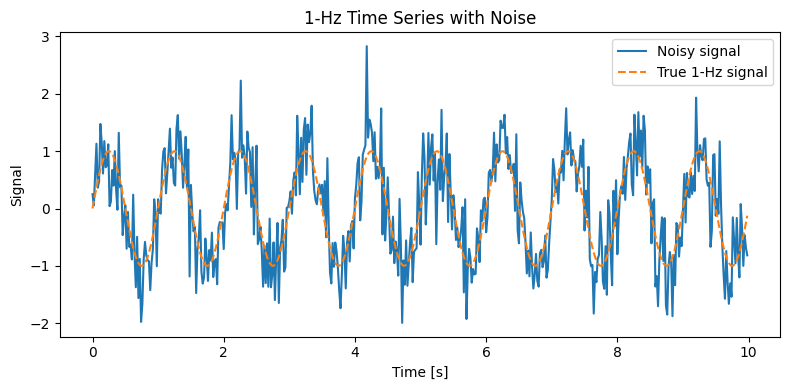

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(t, y, label="Noisy signal")
plt.plot(t, y_clean, "--", label="True 1-Hz signal")
plt.xlabel("Time [s]")
plt.ylabel("Signal")
plt.title("1-Hz Time Series with Noise")
plt.legend()
plt.tight_layout()
plt.show()


## Plot 2: FFT amplitude spectrum

/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: sav

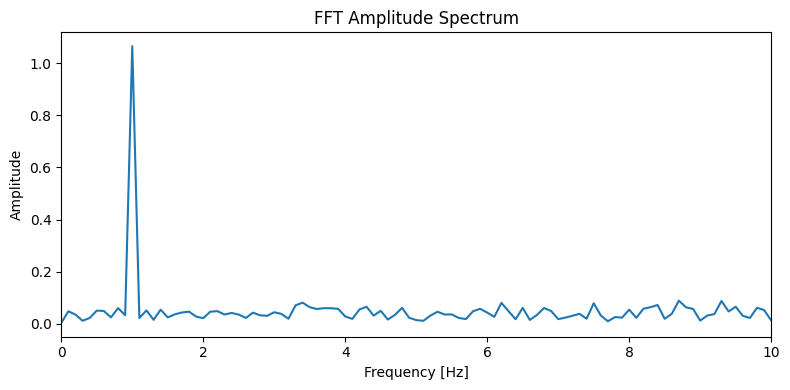

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(freq_pos, amplitude)
plt.xlim(0, 10)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.title("FFT Amplitude Spectrum")
plt.tight_layout()
plt.show()


## Plot 3: power spectrum

/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/home/lq/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: MatplotlibDeprecationWarning: sav

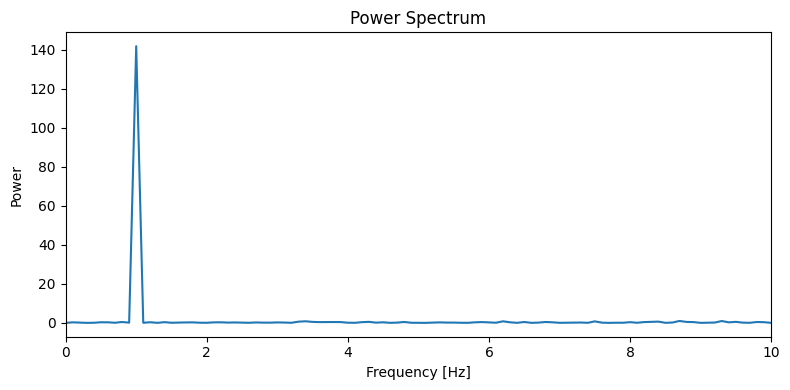

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(freq_pos, power)
plt.xlim(0, 10)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power")
plt.title("Power Spectrum")
plt.tight_layout()
plt.show()
